In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X=np.random.randint(size=(10000,2),high=999,low=0)
print(X)

[[936 123]
 [589 844]
 [126 609]
 ...
 [126 799]
 [240  75]
 [595 292]]


In [3]:
SumX = np.sum(X,axis=1)
print(SumX)

[1059 1433  735 ...  925  315  887]


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchsummary import summary

In [5]:
# Impostiamo il dispositivo su cui eseguire il codice (GPU, se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# Definiamo la classe Dataset di PyTorch
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.x = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(Y,dtype=torch.float32).unsqueeze(1)
        self.len = self.x.shape[0]

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [7]:
#Creiamo i DataSet
perc =0.8 # percentuale di dati per il training
n = int(10000 * perc)
train_dataset = Dataset(X[:n,:], SumX[:n])
test_dataset  = Dataset(X[n:,:], SumX[n:])

In [8]:
# Creiamo i DataLoader per gestire i batch
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [9]:
class DenseNN(nn.Module):
    def __init__(self):
        super(DenseNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))      # Applichiamo ReLU dopo il primo strato
        x = torch.relu(self.fc2(x))      # Applichiamo ReLU dopo il secondo strato
        x = self.fc3(x)                  # Strato finale (senza attivazione, poiché Softmax è implicito nella funzione di perdita)
        return x

In [10]:
model = DenseNN().to(device)  # Spostiamo il modello sul dispositivo scelto
criterion = nn.MSELoss()  # Funzione di perdita per problemi di regressione
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Ottimizzatore Adam

In [11]:
# Funzione per stampare il modello e visualizzare il numero totale di parametri
def visualizza_modello(model, input_size):
    print("Struttura della rete neurale:")
    print(model)
    print("\nRiassunto del modello:")
    summary(model, input_size=input_size)

In [12]:
# Visualizziamo la rete e il numero di parametri
visualizza_modello(model, input_size=(1, 2))

Struttura della rete neurale:
DenseNN(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

Riassunto del modello:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 64]             192
            Linear-2                [-1, 1, 64]           4,160
            Linear-3                 [-1, 1, 1]              65
Total params: 4,417
Trainable params: 4,417
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


Epoch 1/100, Loss: 1067760.0345
Epoch 2/100, Loss: 588780.0565
Epoch 3/100, Loss: 200900.6970
Epoch 4/100, Loss: 44032.7417
Epoch 5/100, Loss: 14442.4983
Epoch 6/100, Loss: 8541.8166
Epoch 7/100, Loss: 5731.4221
Epoch 8/100, Loss: 3937.0762
Epoch 9/100, Loss: 2619.4924
Epoch 10/100, Loss: 1622.3908
Epoch 11/100, Loss: 894.5257
Epoch 12/100, Loss: 438.7213
Epoch 13/100, Loss: 200.3534
Epoch 14/100, Loss: 96.0530
Epoch 15/100, Loss: 54.5868
Epoch 16/100, Loss: 38.0505
Epoch 17/100, Loss: 30.2582
Epoch 18/100, Loss: 25.7623
Epoch 19/100, Loss: 22.6817
Epoch 20/100, Loss: 20.3455
Epoch 21/100, Loss: 18.4913
Epoch 22/100, Loss: 16.9320
Epoch 23/100, Loss: 15.5842
Epoch 24/100, Loss: 14.4241
Epoch 25/100, Loss: 13.4217
Epoch 26/100, Loss: 12.5039
Epoch 27/100, Loss: 11.6681
Epoch 28/100, Loss: 10.9068
Epoch 29/100, Loss: 10.2250
Epoch 30/100, Loss: 9.5654
Epoch 31/100, Loss: 8.9827
Epoch 32/100, Loss: 8.4252
Epoch 33/100, Loss: 7.8932
Epoch 34/100, Loss: 7.4181
Epoch 35/100, Loss: 6.9147
Epo

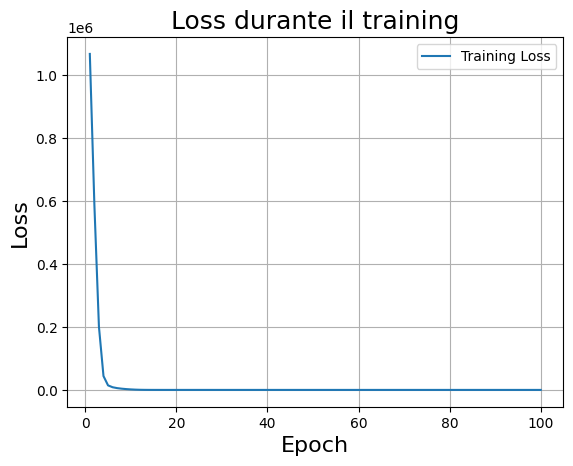

In [13]:
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()  # Mettiamo il modello in modalità training
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Spostiamo i dati sul dispositivo

        optimizer.zero_grad()  # Azzeriamo i gradienti
        outputs = model(inputs)  # Forward pass
        #print(outputs,labels)
        loss = criterion(outputs, labels)  # Calcoliamo la perdita
        loss.backward()  # Backward pass
        optimizer.step()  # Aggiorniamo i pesi

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Visualizziamo l'andamento della perdita durante il training
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Loss durante il training', fontsize=18)
plt.grid()
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import r2_score

model.eval()
all_outputs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        all_outputs.append(outputs.cpu())  # portiamo su CPU
        all_labels.append(labels.cpu())

# concatenare tutti i batch
all_outputs = torch.cat(all_outputs).numpy()
all_labels = torch.cat(all_labels).numpy()

# calcolare R^2
r2 = r2_score(all_labels, all_outputs)
print("R^2 sul set di test:", r2)

R^2 sul set di test: 0.9999991059303284


Considerazioni finali

In [18]:
Z=np.random.randint(size=(1,2),high=999,low=-999)
print(Z)
realSumZ = Z[0,0]+Z[0,1]
modelSumZ = model(torch.tensor(Z,dtype=torch.float32).to(device))
print("Real sum:", realSumZ)
print("Model sum:", modelSumZ.item())

[[ 948 -801]]
Real sum: 147
Model sum: 505.40228271484375


In [19]:
Z=np.random.randint(size=(1,2),high=999999,low=0)
print(Z)
realSumZ = Z[0,0]+Z[0,1]
modelSumZ = model(torch.tensor(Z,dtype=torch.float32).to(device))
print("Real sum:", realSumZ)
print("Model sum:", modelSumZ.item())

[[123402 199625]]
Real sum: 323027
Model sum: 322878.46875


In [16]:
H = [[5, 7], [100, 200], [400, 200], [999, 999]]
realSumH = np.sum(H, axis=1)
modelSumH = model(torch.tensor(H,dtype=torch.float32).to(device))
print("Real sum:",realSumH)
print("Model sum:", modelSumH)

Real sum: [  12  300  600 1998]
Model sum: tensor([[  12.5508],
        [ 300.3548],
        [ 600.2557],
        [1997.6255]], grad_fn=<AddmmBackward0>)
